# Regional Customer-AOV Gap Analysis and Action Plan

## tl;dr

This notebook measures the gap between **customer-average AOV** and the **$120 goal** by region, then converts the diagnosis into a customer-targeting plan.

- Ontario is the largest actionable gap: customer-average AOV is **$96.96**, with **1,317 active customers below $120** and a **$53,736** full-capture next-order gap.
- Quebec ranks second by addressable opportunity (**$46,191**), even though its active-customer mean already exceeds $120. Its opportunity is concentrated among the 61% of active customers still below the goal.
- Nova Scotia is the strongest quick-win pilot: active-customer AOV is **$117.17**, close to the target, with a **$25,399** addressable next-order gap.
- British Columbia should be used as a high-value benchmark. Its active-customer mean is **$129.41**, but 487 active customers remain below $120.
- Alberta requires a different motion: its customer-average AOV gap is wider, so bundles and personalized cross-sell are more suitable than a simple threshold reminder.

The revenue scenarios are **illustrative next-order gap-capture scenarios**, not forecasts or profit estimates.

## Context and methods

### Decision

Choose which regions and customer groups should receive the first AOV-growth tests.

### Metric definition

1. `customer AOV = total customer spend / customer orders`
2. `regional customer-average AOV = mean(customer AOV)`
3. `regional AOV gap = max(0, $120 - regional customer-average AOV)`
4. `active next-order gap = sum(max(0, $120 - customer AOV))` for active customers below $120

Every customer has equal weight in the regional mean. The active next-order gap assumes historical customer AOV is a planning proxy for the next order.

### Key assumptions and caveats

- Active customer: last active within 90 days of the dataset snapshot.
- The 10%, 25% and 50% scenarios represent the percentage of the addressable next-order gap captured.
- These are revenue scenarios, not causal forecasts. Costs, margin, campaign response and product availability are unavailable.
- Small regions and `Unknown` are shown but excluded from the priority score when the sample has fewer than 200 customers.
- Recommendations should be tested with control groups and gross-profit guardrails.

### 1. Import packages and configure the notebook

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

COLORS = {
    "blue": "#35648F",
    "gold": "#C89B32",
    "orange": "#CC6B3D",
    "olive": "#7F8C55",
    "ink": "#2F3742",
    "grey": "#AAB4BF",
    "light": "#E7ECF1",
    "pale_blue": "#D8E5F0",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLORS["ink"],
    "axes.labelcolor": COLORS["ink"],
    "axes.titlecolor": COLORS["ink"],
    "xtick.color": COLORS["ink"],
    "ytick.color": COLORS["ink"],
    "text.color": COLORS["ink"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "#D7DCE1",
    "grid.alpha": 0.75,
    "grid.linewidth": 0.8,
})

def find_data_file() -> Path:
    candidates = []
    configured = os.environ.get("CANADA_VAPES_ANALYSIS_FILE")
    if configured:
        candidates.append(Path(configured))
    candidates.extend([
        Path.cwd() / "analysis_ready.csv",
        Path.cwd() / "upload" / "analysis_ready.csv",
        Path("C:/Users/tooko/Downloads/vape/analysis_ready.csv"),
        Path("C:/Users/tooko/Downloads/vape/analysis_ready.csv"),
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    checked = "\n".join(f"  - {candidate}" for candidate in candidates)
    raise FileNotFoundError("analysis_ready.csv was not found. Checked:\n" + checked)

def money(value: float) -> str:
    return f"${value:,.0f}"

def finish_axis(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

DATA_FILE = find_data_file()
OUTPUT_FOLDER = DATA_FILE.parent / "Regional_Customer_AOV_Gap_outputs"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

AOV_GOAL = 120.00
ACTIVE_DAYS = 90
MIN_PRIORITY_CUSTOMERS = 200
SCENARIO_CAPTURE_RATES = [0.10, 0.25, 0.50]

print("Data file:", DATA_FILE)
print("Output folder:", OUTPUT_FOLDER)
print("AOV goal:", f"${AOV_GOAL:,.2f}")
print("Active-customer window:", ACTIVE_DAYS, "days")

Data file: C:\Users\tooko\Downloads\analysis_ready.csv
Output folder: C:\Users\tooko\Downloads\Regional_Customer_AOV_Gap_outputs
AOV goal: $120.00
Active-customer window: 90 days


### 2. Load and validate the analysis-ready customer dataset

In [2]:
required_columns = {
    "customer_record_id", "last_active", "orders", "total_spend",
    "aov", "region", "days_since_last_active",
}

df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig",
    parse_dates=["last_active", "sign_up"],
)

missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError("Required columns are missing: " + ", ".join(missing_columns))

for column in ["orders", "total_spend", "aov", "days_since_last_active"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

if df["customer_record_id"].duplicated().any():
    raise ValueError("customer_record_id is not unique.")
if df[["orders", "total_spend", "aov", "days_since_last_active"]].isna().any().any():
    raise ValueError("Core analytical fields contain missing or invalid values.")
if (df[["orders", "total_spend", "aov"]].lt(0)).any().any():
    raise ValueError("Negative core values remain in the analysis-ready file.")

df["region"] = df["region"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
snapshot_date = df["last_active"].max().normalize()

print(f"Rows loaded: {len(df):,}")
print(f"Unique customer records: {df['customer_record_id'].nunique():,}")
print(f"Snapshot date: {snapshot_date.date()}")
display(df[["customer_record_id", "region", "orders", "aov", "days_since_last_active"]].head())

Rows loaded: 30,803
Unique customer records: 30,803
Snapshot date: 2026-07-08


,customer_record_id,region,orders,aov,days_since_last_active
0,CV-000001,QC,11,103.70,0
1,CV-000002,ON,54,164.87,0
2,CV-000003,ON,18,150.73,0
3,CV-000004,QC,2,90.32,0
4,CV-000005,NS,49,128.25,0


### 3. Create customer gap bands and recommended actions

In [3]:
df["is_active"] = df["days_since_last_active"].le(ACTIVE_DAYS)
df["aov_gap_to_120"] = (AOV_GOAL - df["aov"]).clip(lower=0)
df["aov_at_or_above_goal"] = df["aov"].ge(AOV_GOAL)

df["gap_band"] = pd.cut(
    df["aov"],
    bins=[-np.inf, 80, 100, 120, np.inf],
    right=False,
    labels=[
        "Large gap (<$80)",
        "Mid gap ($80–<$100)",
        "Near goal ($100–<$120)",
        "At/above $120",
    ],
)

action_map = {
    "Large gap (<$80)": "Replenishment or personalized nurture; avoid blanket discounts",
    "Mid gap ($80–<$100)": "Product bundle or personalized cross-sell",
    "Near goal ($100–<$120)": "$125–$130 threshold, add-on or free-shipping test",
    "At/above $120": "Retention, VIP recognition and referral",
}
df["customer_action"] = df["gap_band"].astype(str).map(action_map)

band_check = pd.crosstab(df["gap_band"], df["is_active"], margins=True)
display(band_check)

is_active,False,True,All
gap_band,,,
Large gap (<$80),11759,2173,13932
Mid gap ($80–<$100),4164,1509,5673
Near goal ($100–<$120),2587,1052,3639
At/above $120,4723,2836,7559
All,23233,7570,30803


## Regional gap scorecard

### 4. Quantify current gaps, active opportunity and priority

In [4]:
regional_rows = []

for region, regional_data in df.groupby("region", dropna=False):
    active_data = regional_data.loc[regional_data["is_active"]]
    active_below = active_data.loc[active_data["aov"].lt(AOV_GOAL)]
    regional_average = float(regional_data["aov"].mean())
    active_average = float(active_data["aov"].mean()) if len(active_data) else np.nan

    regional_rows.append({
        "region": region,
        "customers": len(regional_data),
        "customer_average_aov": regional_average,
        "customer_median_aov": float(regional_data["aov"].median()),
        "customer_aov_gap_to_120": max(0.0, AOV_GOAL - regional_average),
        "customer_aov_gap_percentage": max(0.0, AOV_GOAL - regional_average) / AOV_GOAL,
        "customers_below_120": int(regional_data["aov"].lt(AOV_GOAL).sum()),
        "customers_below_120_share": float(regional_data["aov"].lt(AOV_GOAL).mean()),
        "active_customers": len(active_data),
        "active_customer_average_aov": active_average,
        "active_customer_aov_gap_to_120": max(0.0, AOV_GOAL - active_average) if len(active_data) else np.nan,
        "active_customers_below_120": len(active_below),
        "active_below_120_share": float(active_data["aov"].lt(AOV_GOAL).mean()) if len(active_data) else np.nan,
        "active_near_goal_customers": int(active_data["aov"].between(100, 120, inclusive="left").sum()),
        "active_near_goal_share": float(active_data["aov"].between(100, 120, inclusive="left").mean()) if len(active_data) else np.nan,
        "active_goal_share": float(active_data["aov"].ge(AOV_GOAL).mean()) if len(active_data) else np.nan,
        "average_gap_active_below_120": float(active_below["aov_gap_to_120"].mean()) if len(active_below) else 0.0,
        "addressable_next_order_gap": float(active_below["aov_gap_to_120"].sum()),
    })

region_summary = pd.DataFrame(regional_rows)
region_summary["scenario_10pct_capture"] = region_summary["addressable_next_order_gap"] * 0.10
region_summary["scenario_25pct_capture"] = region_summary["addressable_next_order_gap"] * 0.25
region_summary["scenario_50pct_capture"] = region_summary["addressable_next_order_gap"] * 0.50

eligible = region_summary[
    region_summary["region"].ne("Unknown")
    & region_summary["customers"].ge(MIN_PRIORITY_CUSTOMERS)
].copy()

priority_components = {
    "opportunity_component": ("addressable_next_order_gap", 0.45),
    "active_scale_component": ("active_customers", 0.30),
    "near_goal_component": ("active_near_goal_share", 0.15),
    "sample_scale_component": ("customers", 0.10),
}

for component_name, (source_column, weight) in priority_components.items():
    maximum = eligible[source_column].max()
    eligible[component_name] = 0.0 if maximum <= 0 else eligible[source_column] / maximum * weight

eligible["priority_score"] = 100 * eligible[list(priority_components)].sum(axis=1)
eligible = eligible.sort_values("priority_score", ascending=False).reset_index(drop=True)
eligible["priority_rank"] = np.arange(1, len(eligible) + 1)
eligible["priority_tier"] = pd.cut(
    eligible["priority_rank"],
    bins=[0, 2, 4, 6, np.inf],
    labels=["Priority 1", "Priority 2", "Priority 3", "Monitor"],
)

region_summary = region_summary.merge(
    eligible[["region", "priority_score", "priority_rank", "priority_tier"]],
    on="region",
    how="left",
)

def regional_motion(row):
    if row["region"] == "Unknown":
        return "Fix region data before targeting"
    if pd.isna(row["priority_score"]):
        return "Monitor; sample is too small for regional scaling"
    if row["active_customer_average_aov"] >= AOV_GOAL:
        return "Protect high-value core; cross-sell only below-goal customers"
    if row["active_customer_average_aov"] >= 115:
        return "Quick-win threshold and add-on pilot"
    if row["customer_aov_gap_to_120"] >= 22:
        return "Bundle-led basket building; avoid blanket discounts"
    return "Segmented cross-sell and replenishment test"

region_summary["recommended_regional_motion"] = region_summary.apply(regional_motion, axis=1)
region_summary = region_summary.sort_values(
    ["priority_rank", "addressable_next_order_gap"],
    ascending=[True, False],
    na_position="last",
).reset_index(drop=True)

REGIONAL_SUMMARY_FILE = OUTPUT_FOLDER / "regional_customer_aov_gap_scorecard.csv"
region_summary.to_csv(REGIONAL_SUMMARY_FILE, index=False, encoding="utf-8-sig")

scorecard_columns = [
    "priority_rank", "region", "customers", "customer_average_aov",
    "customer_aov_gap_to_120", "active_customers", "active_customer_average_aov",
    "active_customers_below_120", "addressable_next_order_gap",
    "priority_score", "recommended_regional_motion",
]
display(region_summary[scorecard_columns])

,priority_rank,region,customers,customer_average_aov,customer_aov_gap_to_120,active_customers,active_customer_average_aov,active_customers_below_120,addressable_next_order_gap,priority_score,recommended_regional_motion
0,1.00,ON,9026,96.96,23.04,2009,114.33,1317,"53,736.01",95.60,Bundle-led basket building; avoid blanket disc...
1,2.00,QC,7914,100.23,19.77,2089,122.17,1280,"46,190.87",92.35,Protect high-value core; cross-sell only below...
2,3.00,NS,3751,100.54,19.46,1074,117.17,670,"25,398.86",52.68,Quick-win threshold and add-on pilot
3,4.00,BC,4037,104.85,15.15,837,129.41,487,"18,656.57",44.48,Protect high-value core; cross-sell only below...
4,5.00,AB,2137,94.24,25.76,509,113.87,325,"14,336.83",32.20,Bundle-led basket building; avoid blanket disc...
5,6.00,NB,1318,99.14,20.86,393,121.48,252,"9,488.31",27.29,Protect high-value core; cross-sell only below...
6,7.00,MB,574,99.24,20.76,121,128.86,85,"3,350.23",20.18,Protect high-value core; cross-sell only below...
7,8.00,PE,594,105.65,14.35,187,120.20,114,"4,247.09",18.55,Protect high-value core; cross-sell only below...
8,9.00,SK,564,112.40,7.60,141,145.99,74,"2,700.18",16.50,Protect high-value core; cross-sell only below...
9,10.00,NL,495,97.91,22.09,126,108.85,84,"3,861.38",15.67,Bundle-led basket building; avoid blanket disc...


## Gap visualization

### 5. Compare the current regional average with the $120 goal

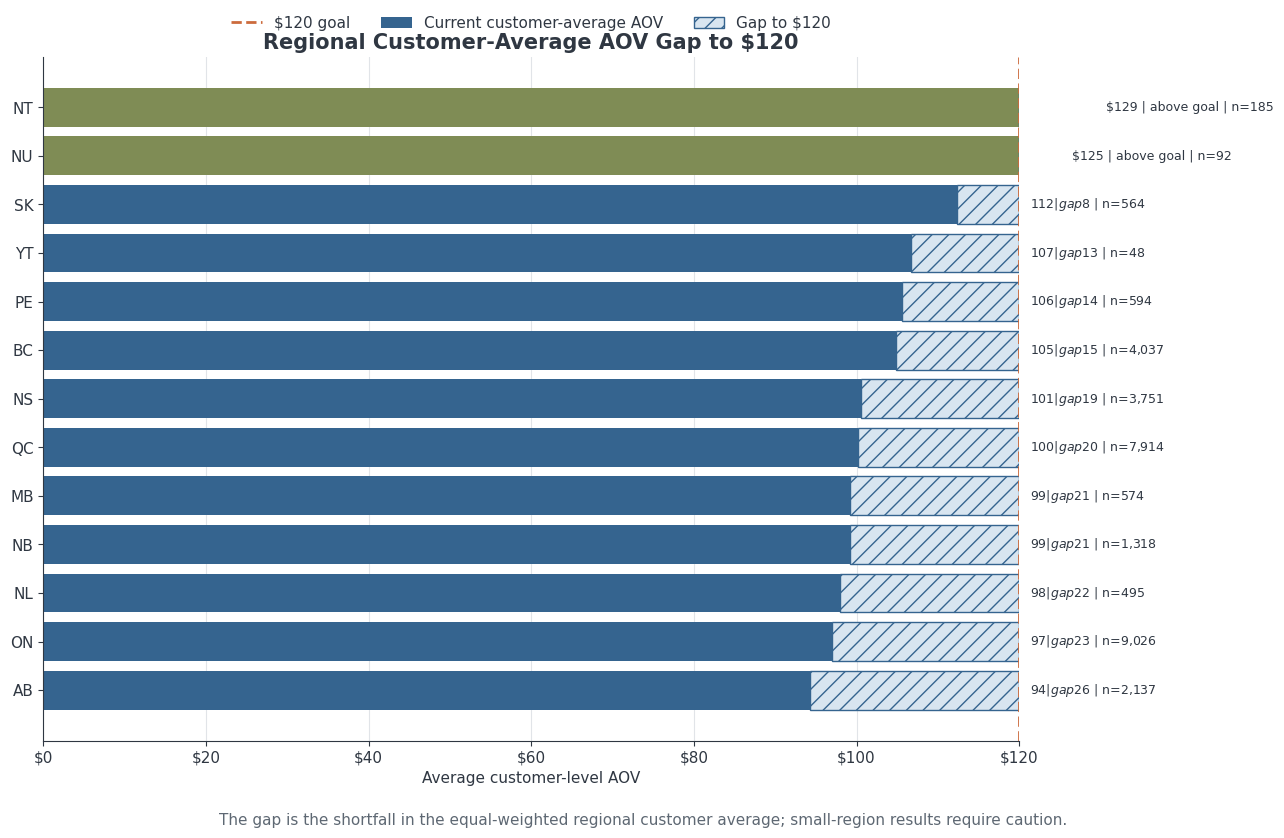

In [5]:
gap_plot = region_summary.loc[region_summary["region"].ne("Unknown")].copy()
gap_plot = gap_plot.sort_values("customer_average_aov", ascending=True)

fig, ax = plt.subplots(figsize=(13, 9))
current_width = gap_plot["customer_average_aov"].clip(upper=AOV_GOAL)
gap_width = (AOV_GOAL - current_width).clip(lower=0)

current_bars = ax.barh(
    gap_plot["region"], current_width,
    color=[COLORS["olive"] if value >= AOV_GOAL else COLORS["blue"] for value in gap_plot["customer_average_aov"]],
    label="Current customer-average AOV",
)
ax.barh(
    gap_plot["region"], gap_width, left=current_width,
    color=COLORS["pale_blue"], edgecolor=COLORS["blue"], hatch="//",
    label="Gap to $120",
)
ax.axvline(AOV_GOAL, color=COLORS["orange"], linestyle="--", linewidth=2, label="$120 goal")
ax.set_title("Regional Customer-Average AOV Gap to $120")
ax.set_xlabel("Average customer-level AOV")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}"))

for position, row in enumerate(gap_plot.itertuples()):
    gap_label = f"gap {money(row.customer_aov_gap_to_120)}" if row.customer_aov_gap_to_120 > 0 else "above goal"
    ax.text(max(row.customer_average_aov, AOV_GOAL) + 1.3, position, f"{money(row.customer_average_aov)} | {gap_label} | n={row.customers:,}", va="center", fontsize=9)

ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.08))
finish_axis(ax)
fig.text(0.5, 0.015, "The gap is the shortfall in the equal-weighted regional customer average; small-region results require caution.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 0.94])
CHART_FILE = OUTPUT_FOLDER / "01_regional_customer_aov_gap_to_120.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Addressable active-customer opportunity

### 6. Rank regions by the full active next-order gap

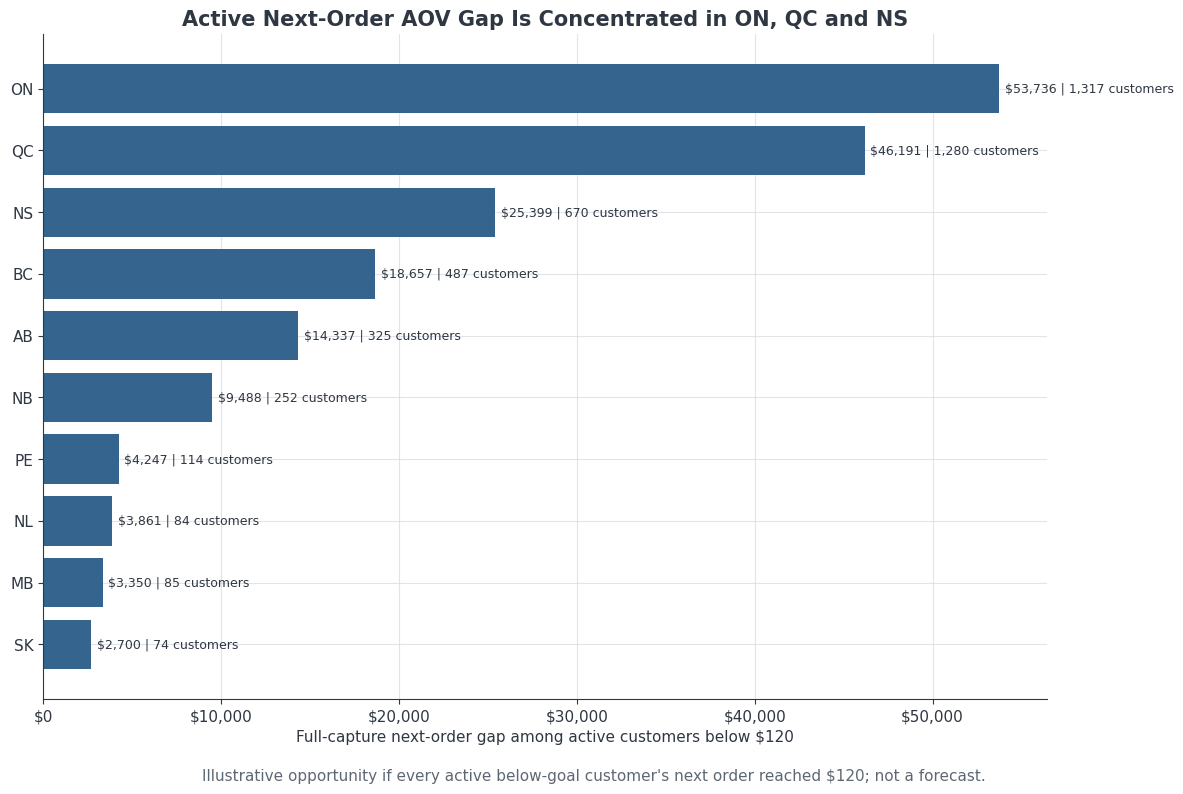

In [6]:
opportunity_plot = region_summary.loc[
    region_summary["region"].ne("Unknown")
].nlargest(10, "addressable_next_order_gap").sort_values("addressable_next_order_gap")

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    opportunity_plot["region"],
    opportunity_plot["addressable_next_order_gap"],
    color=COLORS["blue"],
)
ax.set_title("Active Next-Order AOV Gap Is Concentrated in ON, QC and NS")
ax.set_xlabel("Full-capture next-order gap among active customers below $120")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}"))
labels = [
    f"{money(gap)} | {customers:,} customers"
    for gap, customers in zip(
        opportunity_plot["addressable_next_order_gap"],
        opportunity_plot["active_customers_below_120"],
    )
]
ax.bar_label(bars, labels=labels, padding=4, fontsize=9)
finish_axis(ax)
fig.text(0.5, 0.015, "Illustrative opportunity if every active below-goal customer's next order reached $120; not a forecast.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = OUTPUT_FOLDER / "02_active_next_order_gap_by_region.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Actionable customer mix

### 7. Show which intervention each large region needs

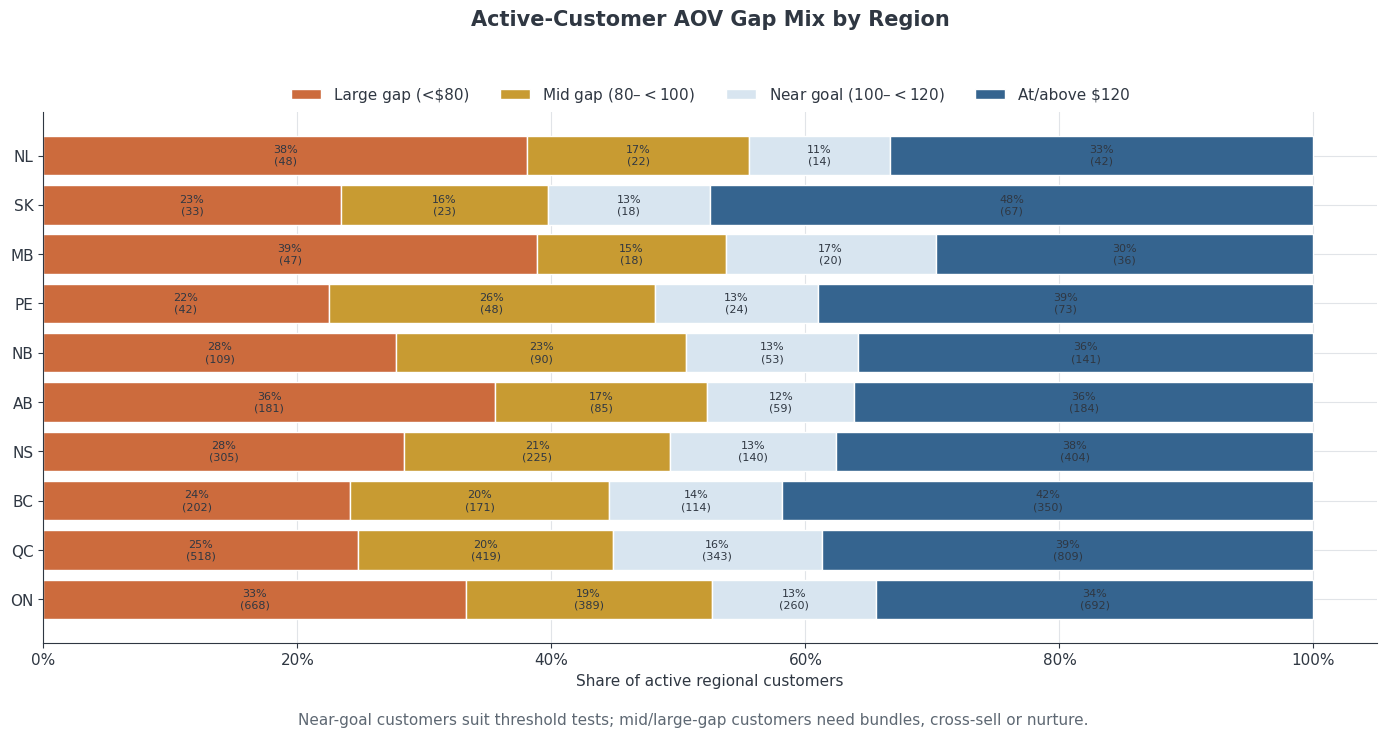

In [7]:
largest_regions = region_summary.loc[
    region_summary["region"].ne("Unknown")
].nlargest(10, "customers")["region"].tolist()

band_order = [
    "Large gap (<$80)",
    "Mid gap ($80–<$100)",
    "Near goal ($100–<$120)",
    "At/above $120",
]

active_mix = pd.crosstab(
    df.loc[df["is_active"] & df["region"].isin(largest_regions), "region"],
    df.loc[df["is_active"] & df["region"].isin(largest_regions), "gap_band"],
).reindex(index=largest_regions, columns=band_order, fill_value=0)
active_mix_share = active_mix.div(active_mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 8))
left = np.zeros(len(active_mix_share))
palette = [COLORS["orange"], COLORS["gold"], COLORS["pale_blue"], COLORS["blue"]]

for band, color in zip(band_order, palette):
    values = active_mix_share[band].to_numpy()
    bars = ax.barh(active_mix_share.index, values, left=left, label=band, color=color, edgecolor="white")
    for index, (bar, value, count) in enumerate(zip(bars, values, active_mix[band])):
        if value >= 0.075:
            ax.text(left[index] + value / 2, bar.get_y() + bar.get_height() / 2, f"{value:.0%}\n({count:,})", ha="center", va="center", fontsize=8, color=COLORS["ink"])
    left += values

ax.set_title("Active-Customer AOV Gap Mix by Region", pad=62)
ax.set_xlabel("Share of active regional customers")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.075))
finish_axis(ax)
fig.text(0.5, 0.015, "Near-goal customers suit threshold tests; mid/large-gap customers need bundles, cross-sell or nurture.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 0.93])
CHART_FILE = OUTPUT_FOLDER / "03_active_customer_gap_mix_by_region.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Reach versus difficulty

### 8. Separate large audiences from difficult gaps

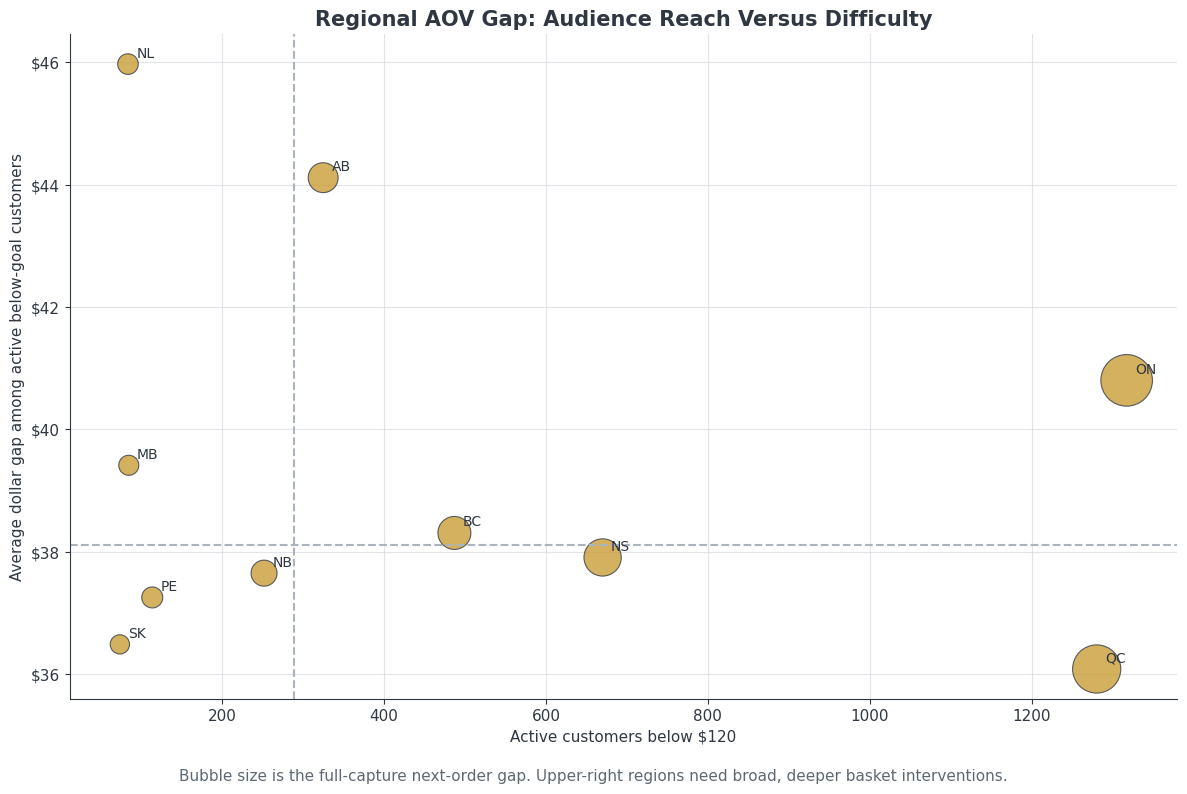

In [8]:
quadrant = region_summary.loc[
    region_summary["region"].ne("Unknown")
    & region_summary["customers"].ge(MIN_PRIORITY_CUSTOMERS)
].copy()

x_mid = quadrant["active_customers_below_120"].median()
y_mid = quadrant["average_gap_active_below_120"].median()
max_opportunity = quadrant["addressable_next_order_gap"].max()
bubble_sizes = 130 + 1_250 * quadrant["addressable_next_order_gap"] / max_opportunity

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(
    quadrant["active_customers_below_120"],
    quadrant["average_gap_active_below_120"],
    s=bubble_sizes,
    color=COLORS["gold"],
    edgecolor=COLORS["ink"],
    linewidth=0.8,
    alpha=0.78,
)
for row in quadrant.itertuples():
    ax.annotate(row.region, (row.active_customers_below_120, row.average_gap_active_below_120), xytext=(6, 5), textcoords="offset points", fontsize=10)

ax.axvline(x_mid, color=COLORS["grey"], linestyle="--", linewidth=1.5)
ax.axhline(y_mid, color=COLORS["grey"], linestyle="--", linewidth=1.5)
ax.set_title("Regional AOV Gap: Audience Reach Versus Difficulty")
ax.set_xlabel("Active customers below $120")
ax.set_ylabel("Average dollar gap among active below-goal customers")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}"))
finish_axis(ax)
fig.text(0.5, 0.015, "Bubble size is the full-capture next-order gap. Upper-right regions need broad, deeper basket interventions.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = OUTPUT_FOLDER / "04_region_reach_vs_gap_difficulty.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Scenario planning

### 9. Estimate incremental next-order revenue under three capture rates

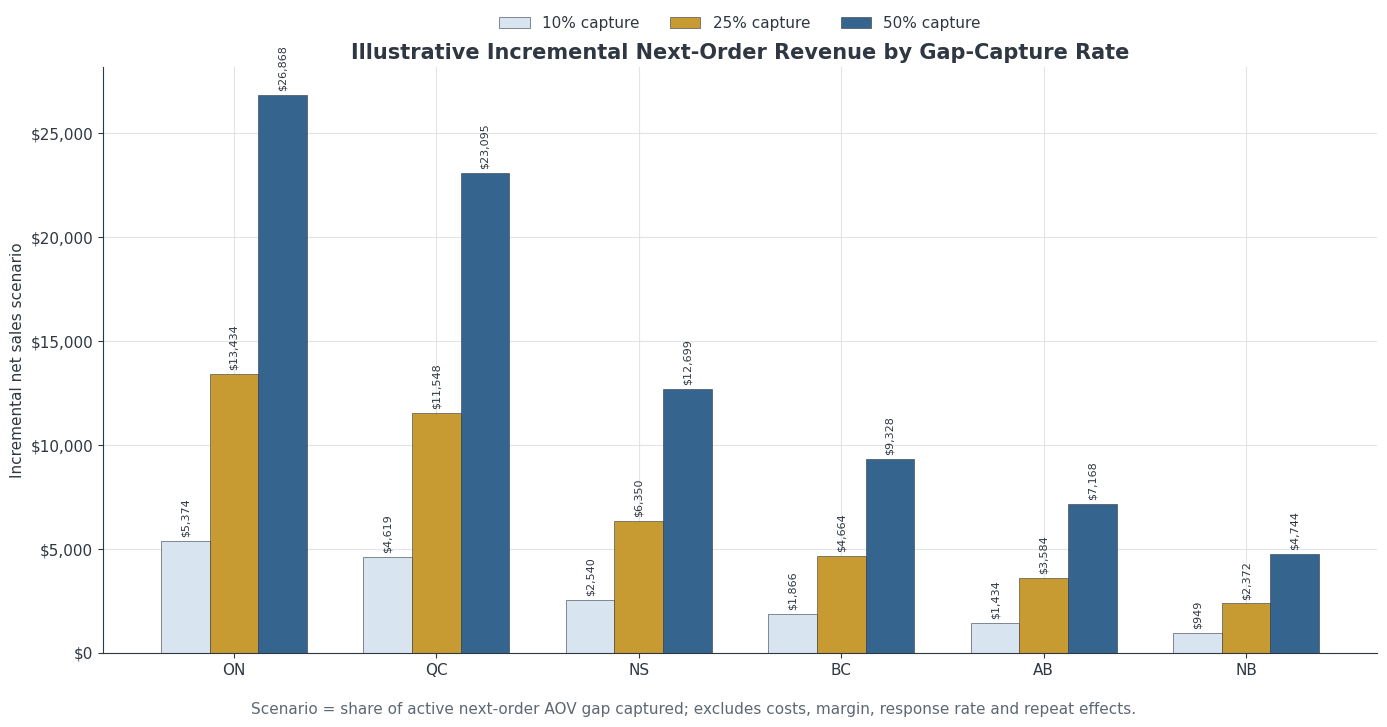

In [9]:
scenario_regions = region_summary.nlargest(6, "addressable_next_order_gap").copy()
scenario_long = scenario_regions.melt(
    id_vars=["region"],
    value_vars=["scenario_10pct_capture", "scenario_25pct_capture", "scenario_50pct_capture"],
    var_name="scenario",
    value_name="incremental_next_order_revenue",
)
scenario_long["capture_rate"] = scenario_long["scenario"].map({
    "scenario_10pct_capture": "10% capture",
    "scenario_25pct_capture": "25% capture",
    "scenario_50pct_capture": "50% capture",
})

x = np.arange(len(scenario_regions))
width = 0.24
fig, ax = plt.subplots(figsize=(14, 8))
scenario_specs = [
    ("scenario_10pct_capture", "10% capture", COLORS["pale_blue"]),
    ("scenario_25pct_capture", "25% capture", COLORS["gold"]),
    ("scenario_50pct_capture", "50% capture", COLORS["blue"]),
]

for offset, (column, label, color) in zip([-width, 0, width], scenario_specs):
    values = scenario_regions[column]
    bars = ax.bar(x + offset, values, width, label=label, color=color, edgecolor=COLORS["ink"], linewidth=0.4)
    ax.bar_label(bars, labels=[money(value) for value in values], padding=3, fontsize=8, rotation=90)

ax.set_xticks(x, scenario_regions["region"])
ax.set_title("Illustrative Incremental Next-Order Revenue by Gap-Capture Rate")
ax.set_ylabel("Incremental net sales scenario")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}"))
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.11))
finish_axis(ax)
fig.text(0.5, 0.015, "Scenario = share of active next-order AOV gap captured; excludes costs, margin, response rate and repeat effects.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 0.92])
CHART_FILE = OUTPUT_FOLDER / "05_regional_next_order_revenue_scenarios.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

SCENARIO_FILE = OUTPUT_FOLDER / "regional_aov_gap_capture_scenarios.csv"
scenario_long[["region", "capture_rate", "incremental_next_order_revenue"]].to_csv(
    SCENARIO_FILE, index=False, encoding="utf-8-sig"
)

## Priority and recommended action

### 10. Rank eligible regions using opportunity, active scale and readiness

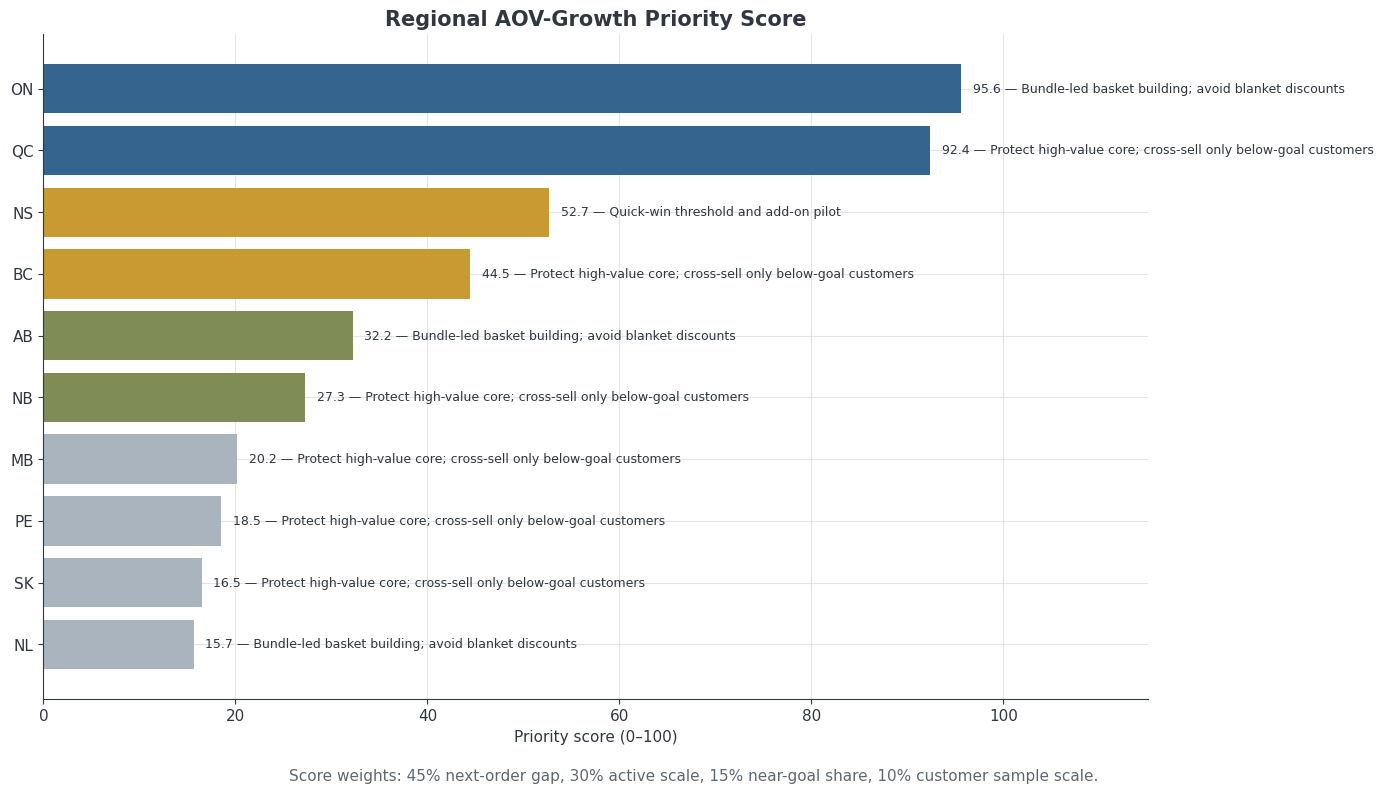

In [10]:
priority_plot = region_summary.loc[region_summary["priority_score"].notna()].copy()
priority_plot = priority_plot.sort_values("priority_score", ascending=True)

tier_colors = {
    "Priority 1": COLORS["blue"],
    "Priority 2": COLORS["gold"],
    "Priority 3": COLORS["olive"],
    "Monitor": COLORS["grey"],
}
bar_colors = [tier_colors[str(tier)] for tier in priority_plot["priority_tier"]]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(priority_plot["region"], priority_plot["priority_score"], color=bar_colors)
ax.set_title("Regional AOV-Growth Priority Score")
ax.set_xlabel("Priority score (0–100)")
ax.set_xlim(0, 115)

for bar, row in zip(bars, priority_plot.itertuples()):
    ax.text(
        row.priority_score + 1.2,
        bar.get_y() + bar.get_height() / 2,
        f"{row.priority_score:.1f} — {row.recommended_regional_motion}",
        va="center",
        fontsize=9,
    )

finish_axis(ax)
fig.text(0.5, 0.015, "Score weights: 45% next-order gap, 30% active scale, 15% near-goal share, 10% customer sample scale.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = OUTPUT_FOLDER / "06_regional_aov_growth_priority_score.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Customer target list

### 11. Export active below-goal customers with specific actions

In [11]:
region_priority_fields = region_summary[[
    "region", "priority_rank", "priority_tier", "priority_score",
    "recommended_regional_motion",
]]

customer_targets = df.loc[
    df["is_active"]
    & df["aov"].lt(AOV_GOAL)
    & df["region"].ne("Unknown"),
    [
        "customer_record_id", "region", "aov", "aov_gap_to_120",
        "orders", "total_spend", "days_since_last_active",
        "gap_band", "customer_action",
    ],
].merge(region_priority_fields, on="region", how="left")

band_priority = {
    "Near goal ($100–<$120)": 1,
    "Mid gap ($80–<$100)": 2,
    "Large gap (<$80)": 3,
}
customer_targets["gap_band_priority"] = customer_targets["gap_band"].astype(str).map(band_priority)
customer_targets = customer_targets.sort_values(
    ["priority_rank", "gap_band_priority", "aov_gap_to_120"],
    ascending=[True, True, True],
    na_position="last",
).drop(columns="gap_band_priority")

TARGET_FILE = OUTPUT_FOLDER / "regional_active_customer_aov_gap_targets.csv"
customer_targets.to_csv(TARGET_FILE, index=False, encoding="utf-8-sig")

print(f"Active below-goal customer targets: {len(customer_targets):,}")
display(customer_targets.head(20))

Active below-goal customer targets: 4,730


,customer_record_id,region,aov,aov_gap_to_120,orders,total_spend,days_since_last_active,gap_band,customer_action,priority_rank,priority_tier,priority_score,recommended_regional_motion
2615,CV-004425,ON,119.96,0.04,6,719.74,36,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...
1591,CV-002688,ON,119.94,0.06,5,599.68,18,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...
1322,CV-002245,ON,119.85,0.15,26,"3,116.12",14,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...
956,CV-001601,ON,119.71,0.29,71,"8,499.48",9,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...
1077,CV-001809,ON,119.34,0.66,70,"8,354.02",10,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...
2569,CV-004346,ON,119.31,0.69,12,"1,431.69",35,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...
2320,CV-003941,ON,119.21,0.79,33,"3,933.91",30,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...
2111,CV-003579,ON,118.78,1.22,59,"7,008.04",26,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...
656,CV-001059,ON,118.74,1.26,14,"1,662.35",6,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...
1415,CV-002406,ON,118.65,1.35,1,118.65,16,Near goal ($100–<$120),"$125–$130 threshold, add-on or free-shipping test",1.00,Priority 1,95.60,Bundle-led basket building; avoid blanket disc...


## Strategic recommendations

In [12]:
def region_value(region, column):
    return region_summary.loc[region_summary["region"].eq(region), column].iloc[0]

recommendations = pd.DataFrame([
    {
        "priority": 1,
        "region": "ON",
        "recommendation": "Launch the first scaled, segmented basket-lift test in Ontario",
        "evidence": f"{int(region_value('ON','active_customers_below_120')):,} active below-goal customers and {money(region_value('ON','addressable_next_order_gap'))} full-capture next-order gap.",
        "action": "Use $125–$130 thresholds for near-goal customers; use bundles and personalized cross-sell for mid/large gaps.",
        "success_measure": "Incremental net sales and gross profit per targeted customer versus control",
    },
    {
        "priority": 2,
        "region": "QC",
        "recommendation": "Protect Quebec's high-value active core while targeting only below-goal customers",
        "evidence": f"Active customer-average AOV is {money(region_value('QC','active_customer_average_aov'))}, but {region_value('QC','active_below_120_share'):.1%} of active customers remain below $120.",
        "action": "Exclude existing high-AOV customers from discounts; run cross-sell and threshold tests only within below-goal bands.",
        "success_measure": "Below-goal share, AOV lift and margin without erosion among the high-value control group",
    },
    {
        "priority": 3,
        "region": "NS",
        "recommendation": "Use Nova Scotia as the quick-win threshold pilot",
        "evidence": f"Active customer-average AOV is {money(region_value('NS','active_customer_average_aov'))}, only {money(region_value('NS','active_customer_aov_gap_to_120'))} below the goal.",
        "action": "Test add-ons, replenishment reminders and a $125–$130 free-shipping or bundle threshold.",
        "success_measure": "Conversion, AOV, incremental net sales and gross profit versus holdout",
    },
    {
        "priority": 4,
        "region": "BC",
        "recommendation": "Use British Columbia as a benchmark and target its below-goal minority",
        "evidence": f"Active customer-average AOV is {money(region_value('BC','active_customer_average_aov'))}, while {int(region_value('BC','active_customers_below_120')):,} active customers remain below goal.",
        "action": "Identify high-value behaviours, then use personalized cross-sell for below-goal customers without blanket offers.",
        "success_measure": "Target-group AOV lift while maintaining regional active AOV above $120",
    },
    {
        "priority": 5,
        "region": "AB",
        "recommendation": "Use bundle-led basket building instead of a simple threshold-only campaign",
        "evidence": f"Customer-average AOV is {money(region_value('AB','customer_average_aov'))}; the mean active below-goal gap is {money(region_value('AB','average_gap_active_below_120'))}.",
        "action": "Use product bundles, multi-buy offers and recommendations; avoid percentage discounts that may reduce margin.",
        "success_measure": "Items per order, AOV, contribution margin and discount cost per incremental dollar",
    },
])

RECOMMENDATION_FILE = OUTPUT_FOLDER / "regional_aov_gap_action_recommendations.csv"
recommendations.to_csv(RECOMMENDATION_FILE, index=False, encoding="utf-8-sig")
display(recommendations)

,priority,region,recommendation,evidence,action,success_measure
0,1,ON,"Launch the first scaled, segmented basket-lift...","1,317 active below-goal customers and $53,736 ...",Use $125–$130 thresholds for near-goal custome...,Incremental net sales and gross profit per tar...
1,2,QC,Protect Quebec's high-value active core while ...,"Active customer-average AOV is $122, but 61.3%...",Exclude existing high-AOV customers from disco...,"Below-goal share, AOV lift and margin without ..."
2,3,NS,Use Nova Scotia as the quick-win threshold pilot,"Active customer-average AOV is $117, only $3 b...","Test add-ons, replenishment reminders and a $1...","Conversion, AOV, incremental net sales and gro..."
3,4,BC,Use British Columbia as a benchmark and target...,"Active customer-average AOV is $129, while 487...","Identify high-value behaviours, then use perso...",Target-group AOV lift while maintaining region...
4,5,AB,Use bundle-led basket building instead of a si...,Customer-average AOV is $94; the mean active b...,"Use product bundles, multi-buy offers and reco...","Items per order, AOV, contribution margin and ..."


## Measurement plan

For every regional test, use a randomized holdout where possible and report:

- **Primary:** customer AOV, incremental net sales per targeted customer and gross profit per targeted customer.
- **Drivers:** conversion rate, items per order, add-on rate, bundle adoption and share reaching $120.
- **Guardrails:** discount cost, gross margin rate, refund rate, unsubscribe rate and repeat purchase rate.
- **Decision rule:** scale only when incremental gross profit is positive and the confidence interval excludes a material loss.

Do not call the scenario values forecasts. A real forecast requires dated order-level transactions, seasonality, campaign exposure, product availability, costs and returns.

### 12. Validate calculations, segment totals and saved outputs

In [13]:
# Entity reconciliation
assert df["customer_record_id"].nunique() == len(df)
assert int(region_summary["customers"].sum()) == len(df)

# Regional mean and gap spot checks
for row in region_summary.itertuples():
    source = df.loc[df["region"].eq(row.region)]
    source_mean = source["aov"].mean()
    source_active_below = source.loc[source["is_active"] & source["aov"].lt(AOV_GOAL)]
    source_opportunity = source_active_below["aov_gap_to_120"].sum()
    assert np.isclose(row.customer_average_aov, source_mean)
    assert np.isclose(row.customer_aov_gap_to_120, max(0, AOV_GOAL - source_mean))
    assert np.isclose(row.addressable_next_order_gap, source_opportunity)

# Mutually exclusive band check
assert int(df["gap_band"].notna().sum()) == len(df)
assert int(active_mix.sum().sum()) == int(df.loc[df["is_active"] & df["region"].isin(largest_regions)].shape[0])

# Customer target reconciliation
expected_targets = df.loc[
    df["is_active"] & df["aov"].lt(AOV_GOAL) & df["region"].ne("Unknown")
].shape[0]
assert len(customer_targets) == expected_targets

required_outputs = [
    REGIONAL_SUMMARY_FILE,
    SCENARIO_FILE,
    TARGET_FILE,
    RECOMMENDATION_FILE,
]
for output_file in required_outputs:
    assert output_file.exists(), output_file

validation = pd.DataFrame({
    "check": [
        "Unique customer grain",
        "Regional customer reconciliation",
        "Regional mean and AOV-gap calculations",
        "Addressable next-order gap calculations",
        "Mutually exclusive gap bands",
        "Customer target reconciliation",
        "Required outputs saved",
    ],
    "result": ["Passed"] * 7,
})
display(validation)

print("Validation status: Ready to share with scenario caveats.")

,check,result
0,Unique customer grain,Passed
1,Regional customer reconciliation,Passed
2,Regional mean and AOV-gap calculations,Passed
3,Addressable next-order gap calculations,Passed
4,Mutually exclusive gap bands,Passed
5,Customer target reconciliation,Passed
6,Required outputs saved,Passed


Validation status: Ready to share with scenario caveats.


## Takeaways

1. Start with **Ontario** for scale, **Nova Scotia** for a quick-win threshold test, and **Quebec** for selective below-goal targeting that protects its strong active-customer average.
2. Use different actions by gap band. A near-goal customer needs a small add-on; a large-gap customer needs bundle construction, replenishment and personalization.
3. Treat British Columbia as a benchmark, not as a reason to discount the entire region.
4. Make gross profit—not AOV alone—the scale decision. The source data lacks product cost, so every campaign requires a margin guardrail.
5. Add order-level products, costs, discounts, campaign exposure and dated transactions before building a causal ROI model or time-series forecast.